<a href="https://colab.research.google.com/github/MClem72026/HF-Analytics-Course/blob/main/Pythonproject2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Im comparing Younger patients vs Older patients using time in hospital.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url = "https://raw.githubusercontent.com/niteen11/DataAnalyticsAcademy/master/Python/dataset_diabetes/diabetic_data.csv"
df = pd.read_csv(url)


In [3]:
print(df.head())

   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...          No      No                   No

In [4]:
print(df.columns)

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [6]:
df_clean = df.dropna(subset=['time_in_hospital'])

In [7]:
younger = df_clean[df_clean['age'].isin(['[20-30)', '[30-40)', '[40-50)'])]
older = df_clean[df_clean['age'].isin(['[60-70)', '[70-80)', '[80-90)'])]


In [8]:
younger_mean = younger['time_in_hospital'].mean()
older_mean = older['time_in_hospital'].mean()

print("Younger Mean Stay:", younger_mean)
print("Older Mean Stay:", older_mean)

Younger Mean Stay: 3.9276972944367268
Older Mean Stay: 4.576489018677374


This section calculated the average hospital stay for Younger patients vs Older patients.

In [9]:
print(df_clean['time_in_hospital'].describe())

count    101766.000000
mean          4.395987
std           2.985108
min           1.000000
25%           2.000000
50%           4.000000
75%           6.000000
max          14.000000
Name: time_in_hospital, dtype: float64


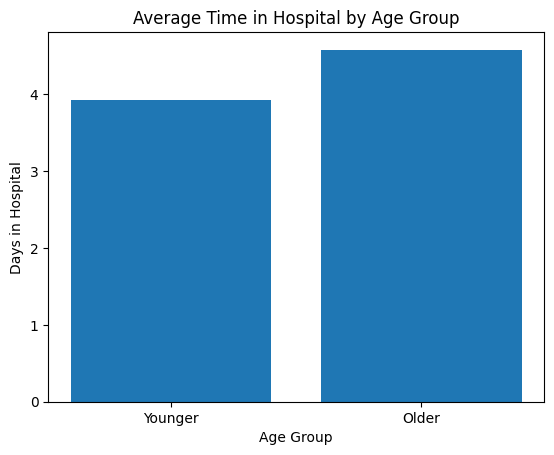

In [12]:
labels = ['Younger', 'Older']
values = [younger_mean, older_mean]

plt.bar(labels, values)
plt.xlabel('Age Group')
plt.ylabel('Days in Hospital')
plt.title('Average Time in Hospital by Age Group')
plt.show()

Chart compares average hospital stay younger vs older patients.

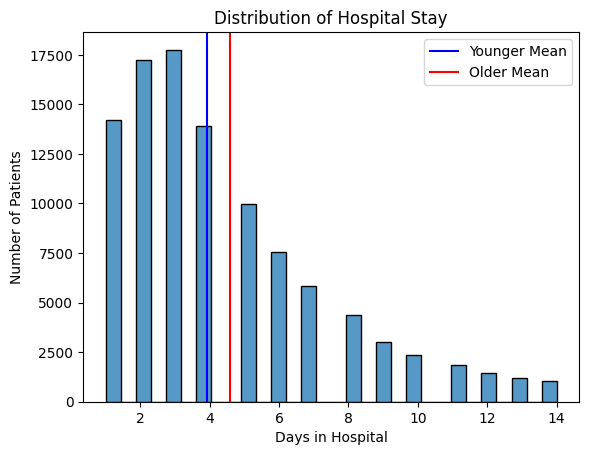

In [15]:
sns.histplot(df_clean['time_in_hospital'], bins=30)

plt.axvline(younger_mean, color= 'blue', label= 'Younger Mean')
plt.axvline(older_mean, color= 'red', label= 'Older Mean')

plt.title('Distribution of Hospital Stay')
plt.xlabel('Days in Hospital')
plt.ylabel('Number of Patients')

plt.legend()
plt.show()

This shows how hospital stay is distrubuted and where each group falls.

In [16]:
age_group_mean = df_clean.groupby('age')['time_in_hospital'].mean().reset_index()

print(age_group_mean)

        age  time_in_hospital
0    [0-10)          2.546584
1   [10-20)          3.191027
2   [20-30)          3.564876
3   [30-40)          3.799735
4   [40-50)          4.039649
5   [50-60)          4.125753
6   [60-70)          4.382244
7   [70-80)          4.590878
8   [80-90)          4.808629
9  [90-100)          4.755818


In [17]:
age_order = ['[20-30)', '[30-40)', '[40-50)', '[50-60)', '[60-70)', '[70-80)', '[80-90)']

age_group_mean['age'] = pd.Categorical(age_group_mean['age'], categories=age_order, ordered=True)

age_group_mean = age_group_mean.sort_values('age')

TypeError: 'value' must be an instance of str or bytes, not a float

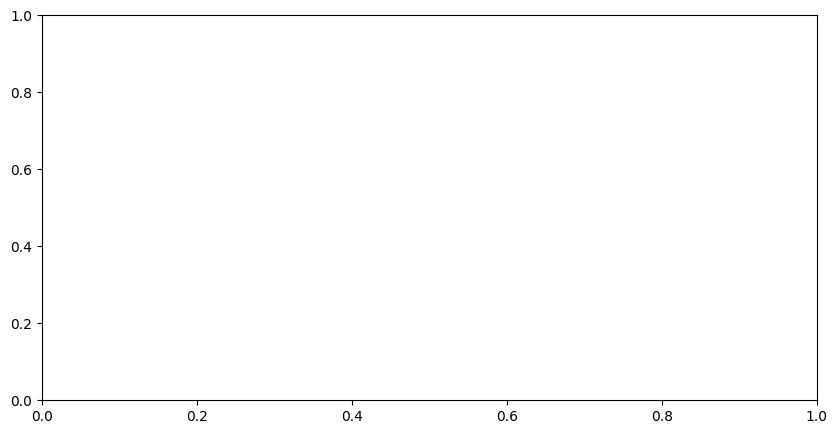

In [18]:
plt.figure(figsize=(10, 5))

plt.bar(age_group_mean['age'], age_group_mean['time_in_hospital'])

plt.title('Average Hospital Stay by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Days in Hospital')

plt.xticks(rotation=30)
plt.show()

In [19]:
age_group_mean = df_clean.groupby('age')['time_in_hospital'].mean().reset_index()

age_order = ['[20-30)', '[30-40)', '[40-50)', '[50-60)', '[60-70)', '[70-80)', '[80-90)']

age_group_mean = age_group_mean[age_group_mean['age'].isin(age_order)]

age_group_mean['age'] = pd.Categorical(age_group_mean['age'], categories=age_order, ordered=True)

age_group_mean = age_group_mean.sort_values('age')

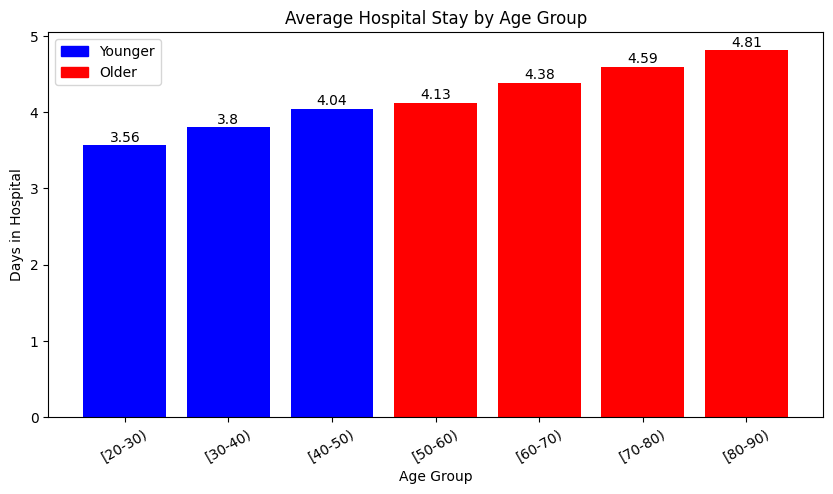

In [29]:

colors = []
for age in age_group_mean['age'].astype(str):
    if age in ['[20-30)', '[30-40)', '[40-50)']:
        colors.append('blue')
    else:
        colors.append('red')

plt.figure(figsize=(10, 5))

bars = plt.bar(age_group_mean['age'].astype(str), age_group_mean['time_in_hospital'], color=colors)

for bar in bars:
  height = bar.get_height()
  plt.text(bar.get_x() + bar.get_width() / 2, height + 0.05, round(height, 2), ha='center')

plt.title('Average Hospital Stay by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Days in Hospital')

plt.xticks(rotation=30)

import matplotlib.patches as mpatches

blue_patch = mpatches.Patch(color='blue', label='Younger')
red_patch = mpatches.Patch(color='red', label='Older')

plt.legend(handles=[blue_patch, red_patch])

plt.show()


This chart uses different colors to distinguish between younger and older age group. Showing hospitals stays increases with the older patients.

This project analyzed diabetes related hospital data using time in hospital as the selected feature. After cleaning the dataset and comparing younger and older patients, the results showed that older patients had a longer average hospital stay. Overall, the analysis suggests that age may be associated with longer hospital stays among diabetic patients.
